In [2]:
"""Deliverable 1, Task 2"""

'Deliverable 1, Task 2'

In [3]:
import pandas as pd
import requests

In [4]:
client_id = open('C:/Users/danie/Documents/NMBU 4.år/Inf 201/W41_42/Client_id_frostmet.txt').read().strip()
print(client_id)


195aadb0-a0cf-4c77-9a8d-2c24e327f3f8


In [ ]:
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {'sources': 'SN17850',
              'elements': 'sum(precipitation_amount P1D)',
              'referencetime':'2025-01-01/2026-01-01'
}

In [6]:
frost_response = requests.get(endpoint, parameters, auth=(client_id, ""))
print(frost_response.status_code)
print(frost_response.text)

200
{
  "@context" : "https://frost.met.no/schema",
  "@type" : "ObservationResponse",
  "apiVersion" : "v0",
  "license" : "https://creativecommons.org/licenses/by/3.0/no/",
  "createdAt" : "2026-10-08T06:09:29Z",
  "queryTime" : 0.461,
  "currentItemCount" : 365,
  "itemsPerPage" : 365,
  "offset" : 0,
  "totalItemCount" : 365,
  "currentLink" : "https://frost.met.no/observations/v0.jsonld?sources=SN17850&elements=sum%28precipitation_amount+P1D%29&referencetime=2025-01-01%2F2026-01-01",
  "data" : [ {
    "sourceId" : "SN17850:0",
    "referenceTime" : "2025-01-01T00:00:00.000Z",
    "observations" : [ {
      "elementId" : "sum(precipitation_amount P1D)",
      "value" : 5.4,
      "unit" : "mm",
      "timeOffset" : "PT18H",
      "timeResolution" : "P1D",
      "timeSeriesId" : 0,
      "performanceCategory" : "C",
      "exposureCategory" : "2"
    }, {
      "elementId" : "sum(precipitation_amount P1D)",
      "value" : 6.6,
      "unit" : "mm",
      "timeOffset" : "PT6H",
    

In [7]:
assert frost_response.status_code == 200

for header_name, header_value in frost_response.headers.items():
    print(f'{header_name:16s}, {header_value}')

x-frost         , cache-status=hits:0/misses:0/noncacheable:1
cache-control   , max-age=-1
date            , Thu, 08 Oct 2026 06:09:29 GMT
content-type    , application/json
content-length  , 237405


In [8]:
frost_payload = frost_response.json()
frost_payload.keys()

dict_keys(['@context', '@type', 'apiVersion', 'license', 'createdAt', 'queryTime', 'currentItemCount', 'itemsPerPage', 'offset', 'totalItemCount', 'currentLink', 'data'])

In [16]:
frost_payload['data'][107]

{'sourceId': 'SN17850:0',
 'referenceTime': '2025-04-18T00:00:00.000Z',
 'observations': [{'elementId': 'sum(precipitation_amount P1D)',
   'value': 4.5,
   'unit': 'mm',
   'timeOffset': 'PT18H',
   'timeResolution': 'P1D',
   'timeSeriesId': 0,
   'performanceCategory': 'C',
   'exposureCategory': '2'},
  {'elementId': 'sum(precipitation_amount P1D)',
   'value': 4.5,
   'unit': 'mm',
   'timeOffset': 'PT6H',
   'timeResolution': 'P1D',
   'timeSeriesId': 0,
   'performanceCategory': 'C',
   'exposureCategory': '2',
   'qualityCode': 0}]}

In [24]:
# create a list that contains ditcs of the timestamp and corresponding precipiation amount
#use this to create a dataframe that can be plotted

"""precipiation_data = [{'Time': pd.to_datetime(entry['referenceTime']),
                      'Daily precipiation amount [mm]': entry['observations'][0]['value']}
                      for entry in frost_payload['data']]"""

precipiation_data = [{'Time': pd.to_datetime(entry['referenceTime']), 
              'Daily precipiation amount [mm]': entry['observations'][0]['value']}
              for entry in frost_payload['data']]

In [20]:
precipiation_df = pd.DataFrame(precipiation_data)
precipiation_df

,Time,Daily precipiation amount [mm]
0,2025-01-01 00:00:00+00:00,5.4
1,2025-01-02 00:00:00+00:00,0.0
2,2025-01-03 00:00:00+00:00,0.1
3,2025-01-04 00:00:00+00:00,0.0
4,2025-01-05 00:00:00+00:00,0.5
...,...,...
360,2025-12-27 00:00:00+00:00,0.0
361,2025-12-28 00:00:00+00:00,0.0
362,2025-12-29 00:00:00+00:00,0.0
363,2025-12-30 00:00:00+00:00,0.0


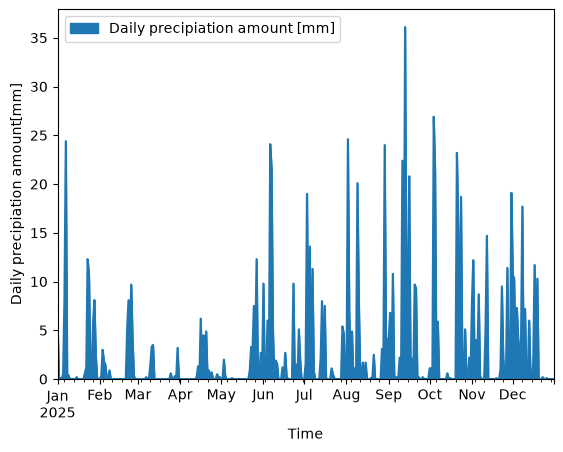

In [35]:
precipiation_plot = precipiation_df.plot(x = 'Time', y = 'Daily precipiation amount [mm]',
    xlabel='Time', ylabel= 'Daily precipiation amount[mm]',kind = 'area')